# Analitica de Datos para Negocios Digitales


## Practica 02: Introduccion al Uso de Python en el Analisis de Datos

Elaborado por: Adriana Rosales Gayosso

Grado/Grupo: 9:A IEVND

Matricula: 230671

**1. Importamos las librerias de Python para la manipulación y analisis de datos**

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as mat
import seaborn as sea

**2. Creamos un DataFrame del Origen de los Datos en este caso un archivo delimitado por comas**

Este comando permite cargar en memoria cache (temporal), los datos que se van a analizar esto utilizando la libreria PANDAS que nos permite la manipulacion de datos.

In [3]:
df=pd.read_csv('UberDataset.csv')

**3. Imprimimos en pantalla los datos cargados para verificar la carga correcta**

Importante: La impresion de los datos del DATAFRAME no da contexto importante  como el numero de filas, el numero de columnas y en caso de datos CUANTITATIVOS  una suma del total de la columna , en caso de los datos CUALITATIVOS nos colocará en texto NaN ( Not as Number) por defecto por no se pueden sumar.

In [4]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**4. Leer los datos de una columna especifica**

El uso de COLUMNA nos permite poder acceder a los datos de la columna del dataframe mostrando los 5 primeros y 5 ultimos, el total de registros y el tipo de datos, cabe mencionar que este comando.

In [5]:
df['PURPOSE']

0        Meal/Entertain
1                   NaN
2       Errand/Supplies
3               Meeting
4        Customer Visit
             ...       
1151     Temporary Site
1152            Meeting
1153     Temporary Site
1154     Temporary Site
1155                NaN
Name: PURPOSE, Length: 1156, dtype: object

**5. Manipulamos los datos cargados para obtener el total de cada valor registrado en la columna**

El metodo value_counts() e una función preprogramada de Python que nos permite agrupar los registro por sus valores y obtener el total de cada valor detectado.() 

In [6]:
df['PURPOSE'].value_counts()

PURPOSE
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Charity ($)          1
Commute              1
Name: count, dtype: int64

**6. Aplicamos la misma función con otra columna**

En este caso vemos que tipos de viaje hizo el conductor, resultando "Bussiness" (Negocios) o "Personal" (Asuntos Personales)

In [7]:
df['CATEGORY'].value_counts()

CATEGORY
Business    1078
Personal      77
Name: count, dtype: int64

**7. Limpiamos los registros de los viajes que no tienen una localización de inicio.**

Para este analisis es importante limpiar los datos de la muestra que nos sirven para nuestro analisis, empezaremos por eliminar los registros (Filas) de aquellos viajes que nos registraron un destino localizable. Para ello utilizamos el comando logico de no igualdad (!=) pára filtrar el dataframe, esto nos arrojara un resultado de booleano "True" para los qu etienen un destino localizable y "False" para los que no.

In [8]:
df['STOP']!='Unknown Location'

0        True
1        True
2        True
3        True
4        True
        ...  
1151    False
1152    False
1153     True
1154     True
1155     True
Name: STOP, Length: 1156, dtype: bool

**8. Limpiamos los registros de los viajes que no tienen una localizacion de inicio.**

In [9]:
df=df[df['STOP']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**9. Sobreescribimos del dataframe (df)**

Para eliminar de nuestro analisis, es decir que el documento de origwn de los datos (csv) sigue sin cambios adignamos el resultado del filtrado.

In [10]:
df=df[df['START']!='Unknown Location']

**10. Volvemos a imprimir el dataframe**

En este resultado podemos observar que el numero dataframe cuenta solo con 1007 filas a diferencia del original que tenia 1156, es decir se eliminaron 149 registros que no tenian un destino localizable.

In [11]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**11. Repetimos el proceso de limpieza ahora para los viajes que no tienen un origen localizable (START)**

En este caso realizamos toda la limpieza en una sola operación, obteniendo una actualizaciobn del df que ocuparemos para el analisis de datos reduciendo de 1007 a 945 registros, intuyendo que hay 2 viajes que tuvieron un destino (STOP) pero no un origen (START)

In [12]:
df=df[df['START']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**LIMPIAMOS LOS REGISTROS DE LOS VIAJES QUE NO SON LOCALIZABLES**

In [13]:
def value(val):
    val=str(val)
    return val.replace('?','a')
df['START']=df['START'].apply(value)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**12.Conceptos de Repaso**

12.1 funciones o metodos en Python
    una funcion o mmetodo es un bloque de codigo reutilizable que realiza una tarea especifica sirve parta evitar repetir instrucciones y organizar mejor los programas.
    En el lenguaje de Programacion de Python las funciones son declaradas con la palabra reservada **def** y para ejecutarlas basta con escribir el nombre que se le asigno a ai 
    misma, el uso de () es para enviar los datos de entrada en caso de que sean necesarias.

*Definicion*

In [14]:
def saludar():
    print("Hola, Bienvenida a python para el Analisi de Datos")

*Llamada*

In [15]:
saludar()

Hola, Bienvenida a python para el Analisi de Datos


12.2 Funciones que reciben un parametro o datos de entrada. En algunas ocasiones es necesario enviar datos para ejecucion del metodo para ello debemos declararlo en
la definicion de la funcion entre ()

*Definicion*

In [16]:
def saludar_nombre(nombre):
    return f"Hola, {nombre} Bienveni@ a Python para el analisis de Datos"

In [17]:
saludar_nombre("Marco")

'Hola, Marco Bienveni@ a Python para el analisis de Datos'

In [18]:
saludar_nombre("Adri")

'Hola, Adri Bienveni@ a Python para el analisis de Datos'

12.3 Funciones que mandan llamar otras funciones y que regresan al resultado de un procesamiento, en este caso utilizaremos una funcion predefinida en Python
denomina replace que nos permite sustituir letras en una cadena de texto.

*Definicion*

In [19]:
def sustituir_vocales(texto):
    texto = texto.replace("A", "4")
    texto = texto.replace("a", "4")

    texto = texto.replace("E", "3")
    texto = texto.replace("e", "3")

    texto = texto.replace("I", "1")
    texto = texto.replace("i", "1")

    texto = texto.replace("O", "0")
    texto = texto.replace("o", "0")

    texto = texto.replace("U", "∪")
    texto = texto.replace("u", "∪")

    return texto

*Llamado*

In [20]:
print(sustituir_vocales(saludar_nombre("Marco")))

H0l4, M4rc0 B13nv3n1@ 4 Pyth0n p4r4 3l 4n4l1s1s d3 D4t0s


**Limpieza de letras ilegibles**

Ejecutamos el proceso de sustitucion de las letras ilegible (para este caso de estudio solo hay letras a con tilde que se cargaron con un?. y se limpia con una "a" para
mejor compresion del analisis.

In [21]:
df['START'] = df['START'].astype(str).str.replace('?','a')
df['STOP'] = df['STOP'].astype(str).str.replace('?','a')
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**14.Rellenar datos vacios por un valor generico asignado**

Durante el proceso de limpieza y Transformcacion de los datos, existe la posibilidad de corregir datos que no se encuentran para este caso usaremos una
funciones de Pnadas llamada filina(sirve para rellenar los datos no disponibles (not avalilable)

In [22]:
df['PURPOSE'].fillna('Others', inplace=True)
df

C:\Users\PC-14\AppData\Local\Temp\ipykernel_14216\2042178618.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PURPOSE'].fillna('Others', inplace=True)


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**Medidas de Tendnci Central**

Una vez terminada la fase de limpieza de datos comenzamos con la estadistica basica en este caso consultaremos las medidas de tendencia central siendo total media 
Cuartiles y Desviacion Estandar, Maximo y Minimo.

Utilizando en metodo describe de nuestro datafrma, se buscaran todos los datos cuantitatoivos (Numericos) de la muestra y realizara el calculo de estos valores para este
caso en especifico solo tenemos la columna MILES la cual hace referencai al total de Millas Terrestreas (1.609 km) recorridas por el conductor en un servicio de viaje
de UBER.

In [23]:
df.describe()

,MILES
count,945.000000
mean,22.809841
std,397.276813
min,0.500000
25%,2.600000
50%,5.300000
75%,9.900000
max,12204.700000


Para el caso de Mediana y Moda estas deben ser calculadas por separado a traves de las funciones mode y median

In [24]:
print(df['MILES'].mode())

0    9.9
Name: MILES, dtype: float64


In [25]:
print(df['MILES'].median())

5.3


En **CONCLUSION** este dataframe nos permite analizar una pequeña muestra de **945** Viajes realizados a traves de la aplicasion de UBER, determinacion
que la distancia minuma registrada es de **.5** millas y las maxima de **12204** millas, con un proomediode **22.8** sillas, siendo la doistancia esas
repetidas de 5.3 mllas.

**16. Limpieza de Datos Segmentar la Fecha del viaje, ignorando la HH:MM:SS**

In [26]:
def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-','/')
df['START_DATE']=df['START_DATE'].apply(val)

def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-','/')
df['START_DATE']=df['END_DATE'].apply(val)
df
    

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**17. Eliminamos la ultima fila de totales**

La ultima fila de totales no es necesaria para la graficacion dado que podria generar error en la representacion de datos, por ello la 
eliminamos del Dataframe usando el comando drop y el numero de la posicion de la fila a elimainar enserrada entre corchetes[]

In [39]:
df.drop([1155], inplace=True)
df

KeyError: '[1155] not found in axis'

**Documentacio**

Para comprender mejor la distribución de las distancias de los viajes (columna MILES), se calcularon la Moda y la Mediana utilizando las funciones nativas de Pandas.
El código tiene como objetivo limpiar y segmentar los datos de la columna 'MILES' mediante el cálculo de los percentiles 5 y 95 para identificar y descartar los valores atípicos (viajes extremadamente cortos y largos). Las variables b y a almacenan estos límites estadísticos, respectivamente; sin embargo, debido a que las condiciones de filtrado se ejecutan de manera consecutiva e independiente (df3 = ), la última línea sobrescribe a la anterior, provocando que el resultado final (df3) solo conserve los registros menores al percentil 95, omitiendo el descarte de los valores inferiores.

In [31]:
a = df['MILES'].quantile(0.95)
b = df['MILES'].quantile(0.05)
df3 = df[df['MILES']>b]
df3 = df[df['MILES']<a]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
5,01/06/2016,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016 16:03,Business,Karachi,Karachi,4.6,Errand/Supplies
1148,12/30/2016,12/30/2016 17:08,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting


**19.Calculo de la Desviacion Estandar**

para entender que tan variables o dispersas son las distancias de los viajes

In [34]:
df3['STD']=df.MILES.std()
df

C:\Users\PC-14\AppData\Local\Temp\ipykernel_14216\1864245730.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['STD']=df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1148,12/30/2016,12/30/2016 17:08,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


**20. Estimar el valor de Z-Score o Puntuacion Z**

La dispersion de los datos, es decir que tan variados o diferentes son, utilizamos esta formula estadistica para poder continuar con el analisis EDA (Exploratory Data Analisys)

In [41]:
df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805,-0.228442
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016 16:03,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016 17:08,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


**21. Filtramos aquello que no este en el rango de -1 y 1**

In [50]:
df['MILES'].describe()

count    944.000000
mean       9.905297
std       21.472805
min        0.500000
25%        2.600000
50%        5.300000
75%        9.900000
max      310.300000
Name: MILES, dtype: float64

In [48]:
df3['MILES'].describe()

count    896.000000
mean       6.344196
std        4.849186
min        0.500000
25%        2.500000
50%        4.900000
75%        9.025000
max       25.600000
Name: MILES, dtype: float64

In [36]:
df3=df3[(df3.Z>-1) & (df3.Z<1)]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805,-0.228442
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016 16:03,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016 17:08,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


**22. Graficacion Basica para un Analisis mas visual y Simplificado**

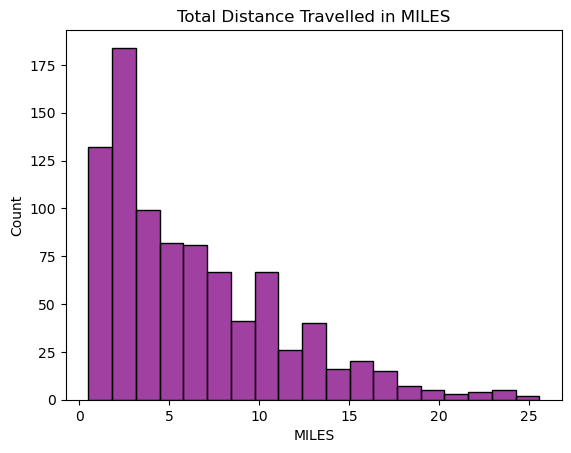

In [53]:
mat.title('Total Distance Travelled in MILES')
sea.histplot(df3.MILES,color='Purple')
mat.show()

**23.Grafico de clasificasion de viajes por CATEGORIA**

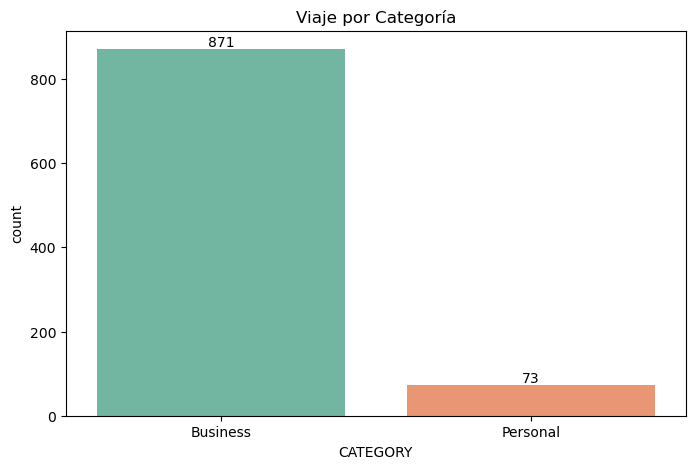

In [65]:
fig, ax = mat.subplots(figsize=(8, 5))

grafica = sea.countplot(
    data=df,
    x='CATEGORY',
    hue='CATEGORY',
    palette='Set2',
    legend=False,
    ax=ax
)
b
# Título
ax.set_title('Viaje por Categoría')

# Agregar etiquetas con totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()

**24. Grafica de viajes por proposito (PURPOSE)**

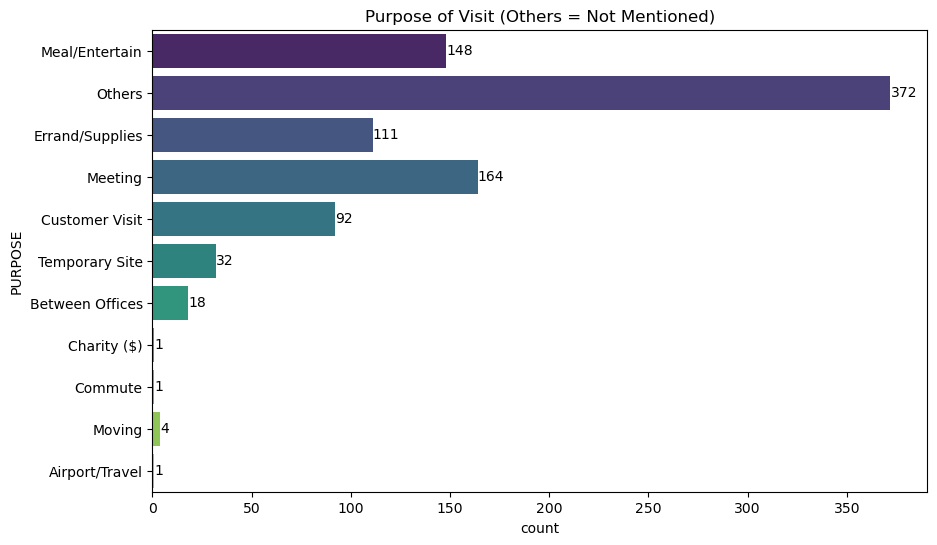

In [63]:
fig, ax = mat.subplots(figsize=(10, 6))

grafica = sea.countplot(
    data=df,
    y='PURPOSE',
    hue='PURPOSE',
    dodge=False,
    palette='viridis',
    legend=False
)

# Título
ax.set_title('Purpose of Visit (Others = Not Mentioned)')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()

**25.Grafica de lugar de abordaje (START)**

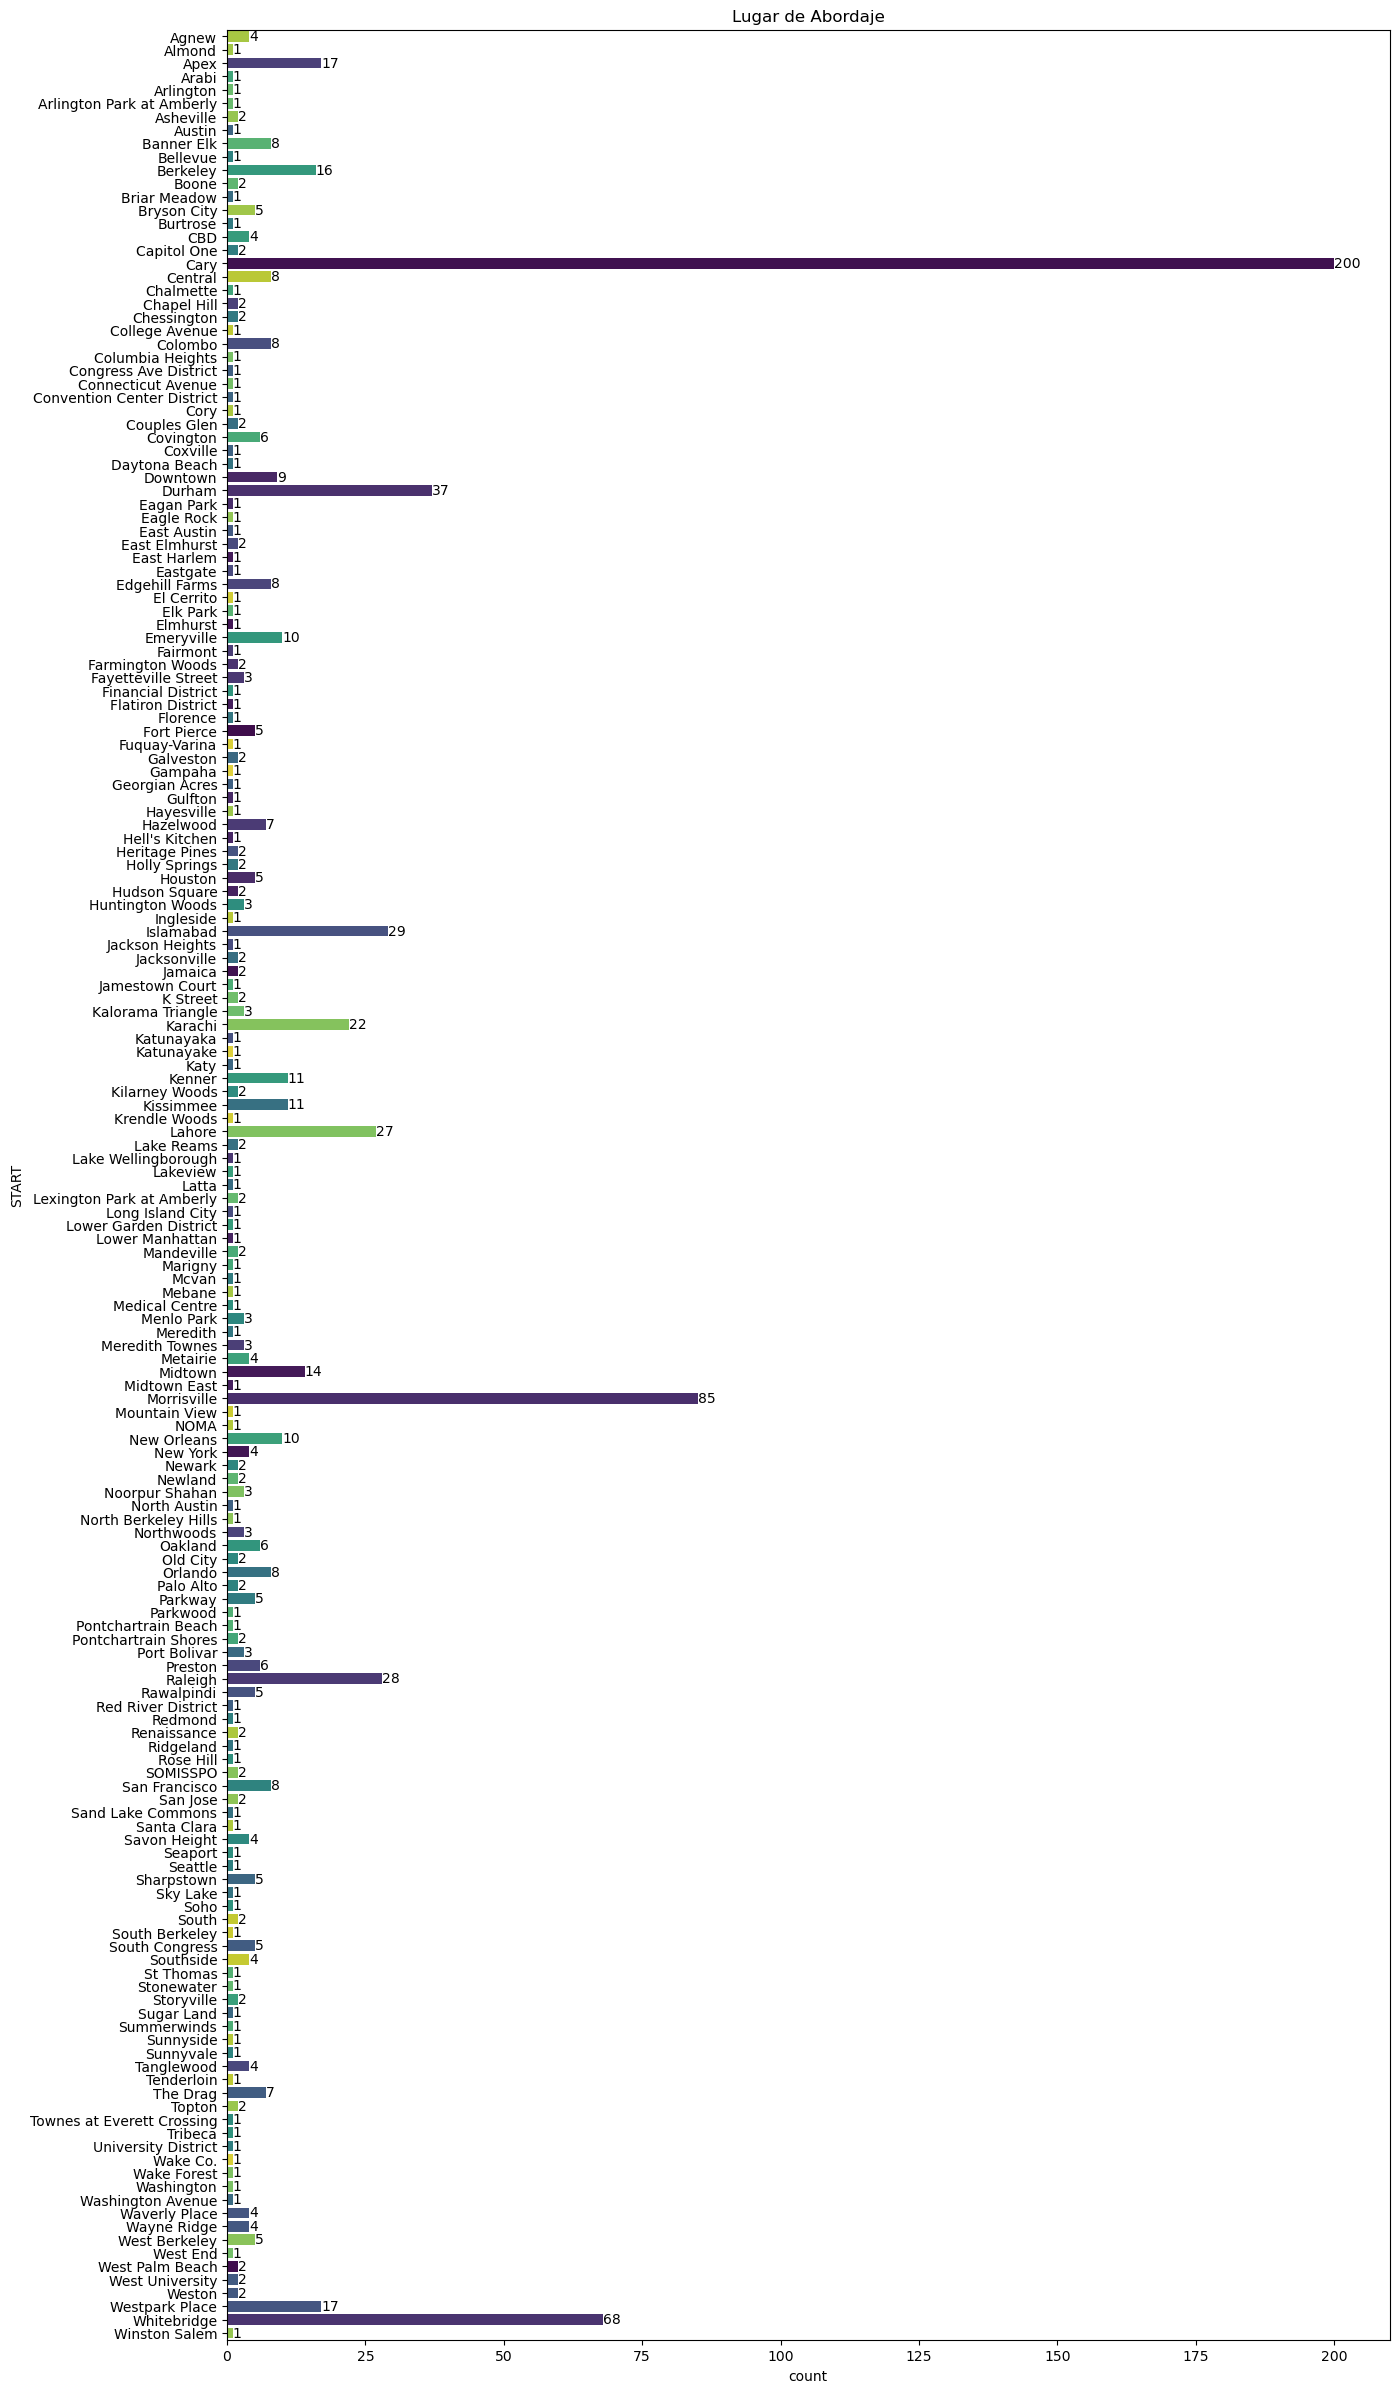

In [68]:
fig, ax = mat.subplots(figsize=(15, 30))

# Ordenar alfabéticamente
orden = sorted(df['START'].dropna().unique())

grafica = sea.countplot(
    data=df,
    y='START',
    order=orden,
    hue='START',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Lugar de Abordaje')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()

**27.Grafica de Lugar de Descanzo (S)**

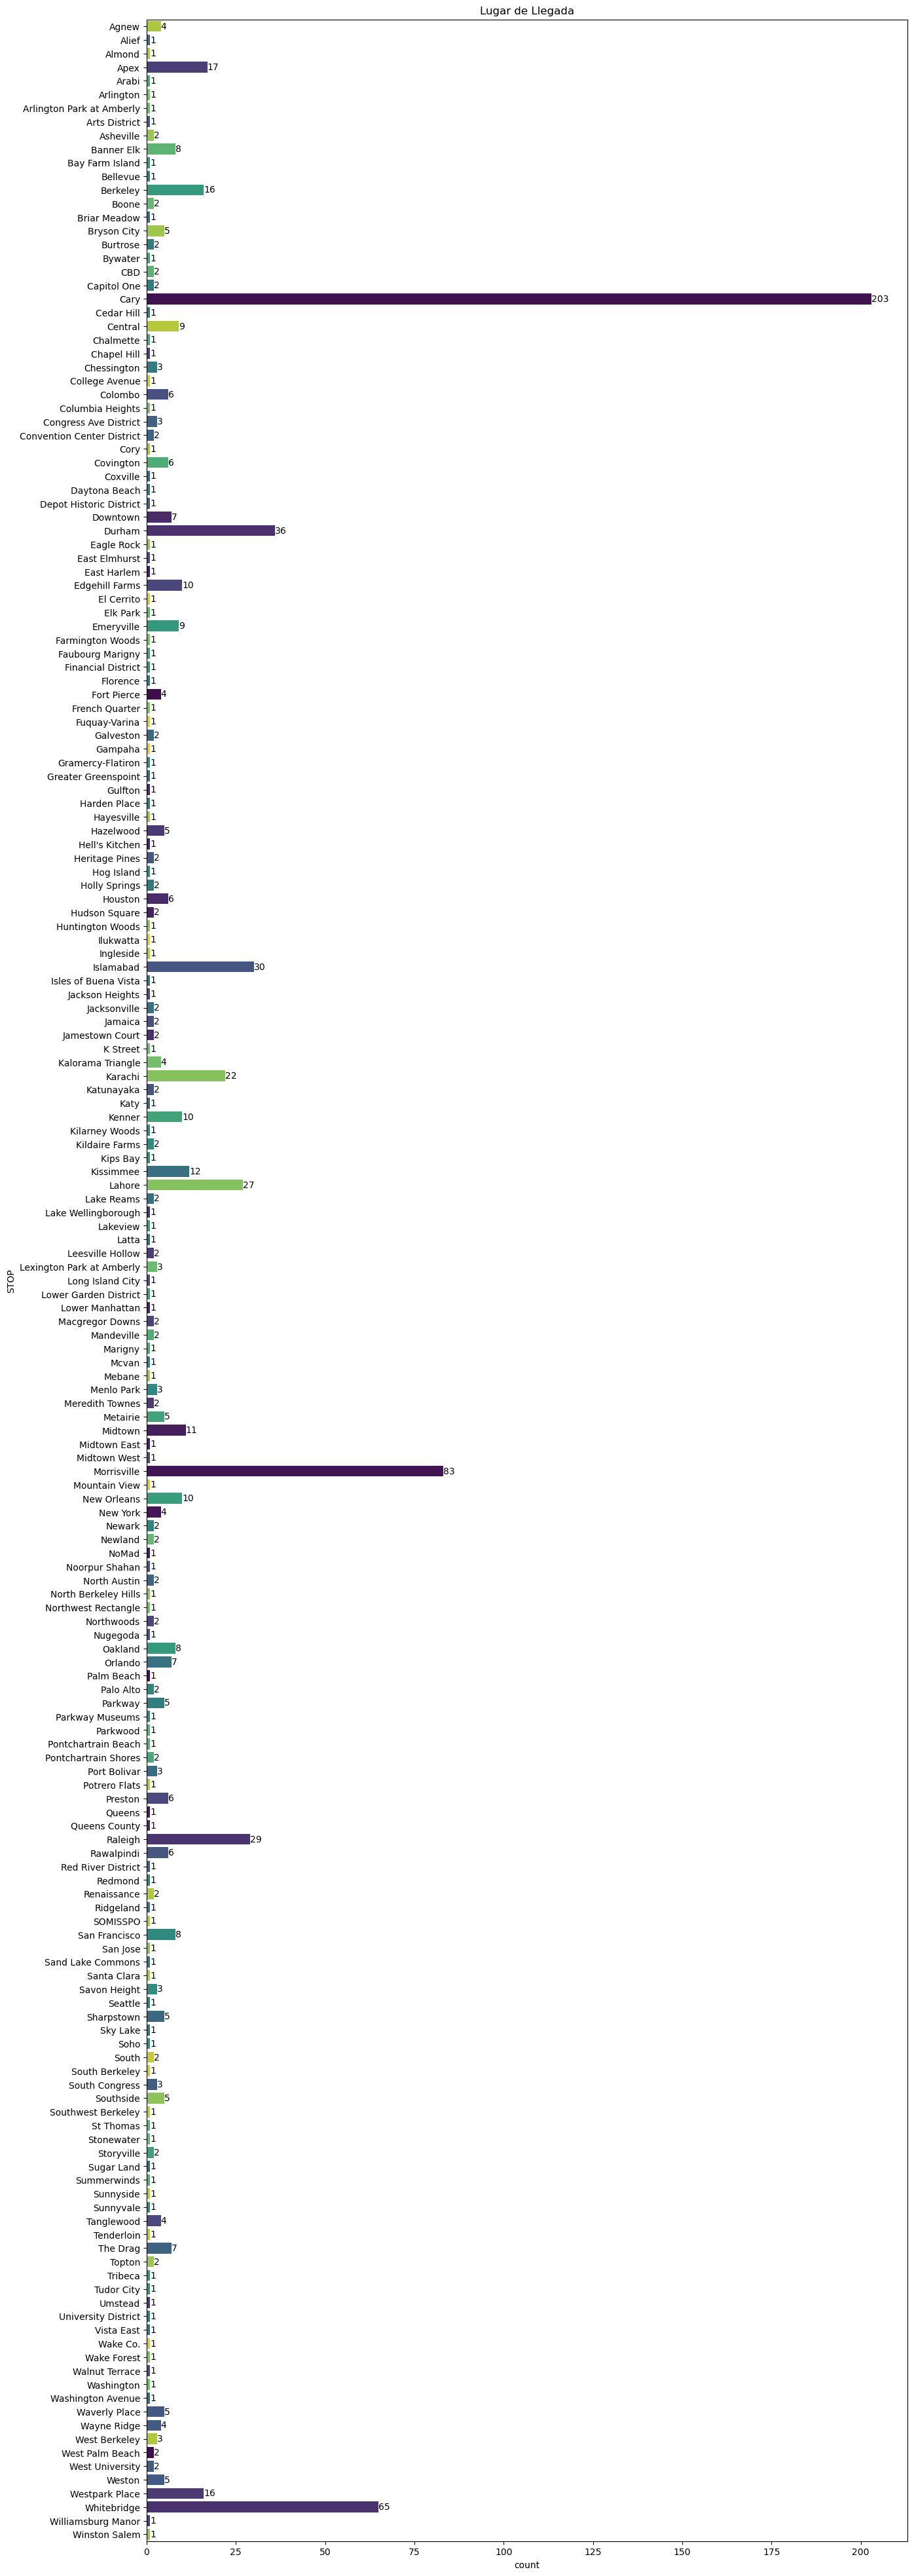

In [70]:
fig, ax = mat.subplots(figsize=(15, 50))

# Ordenar alfabéticamente
orden = sorted(df['STOP'].dropna().unique())

grafica = sea.countplot(
    data=df,
    y='STOP',
    order=orden,
    hue='STOP',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Lugar de Llegada')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()

**28.Conclusion**

Esta práctica demostró la efectividad de Python y su ecosistema de librerías especializadas (pandas, numpy, matplotlib y seaborn) como un pilar tecnológico capaz de transformar datos brutos del UberDataset.csv en conocimiento estratégico de alto valor para los Negocios Digitales.
A través de una exploración inicial de las variables y un riguroso proceso de Data Wrangling, se logró identificar anomalías estructurales y valores nulos. Al eliminar de manera lógica los registros inválidos y las ubicaciones desconocidas, la muestra se redujo de 1,156 a 945 filas útiles. Este paso no fue puramente técnico, sino una acción metodológica fundamental que garantizó la integridad del análisis, mitigando sesgos y eliminando ruidos que habrían conducido a conclusiones erróneas o inversiones de riesgo en un entorno empresarial real.
El análisis descriptivo y la posterior fase de visualización revelaron un patrón de comportamiento con una marcada orientación comercial y corporativa. El predominio absoluto de la categoría Business frente a la de uso Personal, sumado a que los propósitos de viaje más recurrentes fueron las reuniones de negocios y los compromisos de trabajo, dibuja con claridad el perfil del consumidor principal de este servicio: un usuario profesional que prioriza la optimización de sus tiempos de traslado durante su jornada laboral.
En conclusión, el desarrollo e implementación de este flujo fundamental de analítica probó ser una herramienta indispensable para los Negocios Digitales. El valor real de este proceso radica en su capacidad de convertir métricas aisladas en ventajas competitivas: desde la comprensión matemática de las distancias recorridas hasta la identificación de zonas clave de origen y destino. De este modo, la ciencia de datos aplicada se consolida como el activo más importante para optimizar recursos, diseñar estrategias de mercado personalizadas y tomar decisiones comerciales accionables, ágiles y respaldadas por las dinámicas reales de la movilidad urbana.
